In [25]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from matplotlib.widgets import Slider
%matplotlib widget
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/Passive"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
db_ = []
#iexp = 0
db_.append({'mname': 'VG56', 'datexp': '2026_07_13', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_14', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_14', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG70', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})
db_.append({'mname': 'VG69', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})
db_.append({'mname': 'VG66', 'datexp': '2026_08_12', 'blk':'3','stim':'8x4textures'})
db_.append({'mname': 'VG64', 'datexp': '2026_08_12', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG63', 'datexp': '2026_08_12', 'blk':'2','stim':'8x4textures'})

In [3]:
import mat73
import os
def load_timeline(db):    
    mname, datexp, blk = db['mname'], db['datexp'], db['blk']
    root = os.path.join('Z:/data/PROC', mname, datexp, blk)
    fname     = 'Timeline_%s_%s_%s_RAW.mat'%(mname, datexp, blk) 
    fnamepath = os.path.join(root, fname) 
    data = mat73.loadmat(fnamepath)
    return data

In [29]:
timeline = load_timeline(db_[3])
pup = timeline["TL"]["beh"]["pup"]
pupx_median = medfilt(pup[1,:], 9) # pupil should be 1, 2 and 3?
pupy_median = medfilt(pup[2,:], 9) # pupil should be 1, 2 and 3?
pup_size = pup[3,:]

ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


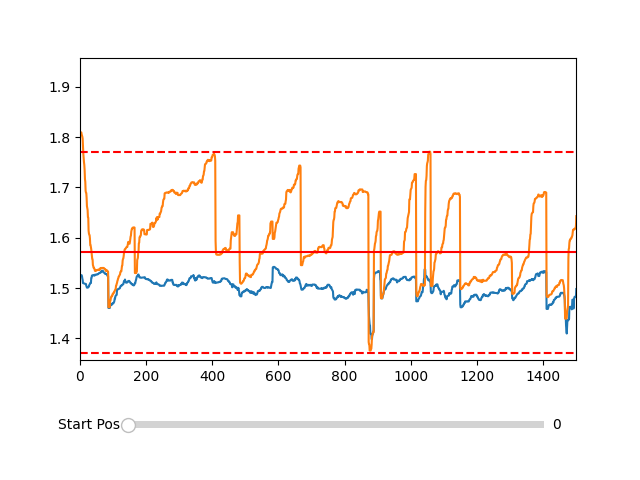

In [27]:
plot, Axis = plt.subplots()
plt.subplots_adjust(bottom=0.25)
x = np.arange(len(pupx_median))
l = plt.plot(x, pupx_median)
t = plt.plot(x, pupy_median)
avg= np.pi/2
plt.axhline(y=avg, color='r', linestyle='-')
plt.axhline(y=avg+0.2, color='r', linestyle='--')
plt.axhline(y=avg-0.2, color='r', linestyle='--')
window_size = 1500

Axis.set_xlim(0, window_size)
Axis.set_ylim(np.min(pupx_median), np.max(pupy_median))
slider_color = 'White'
max_slider_val = max(0, len(pupx_median) - window_size)

axis_position = plt.axes([0.2, 0.1, 0.65, 0.03], facecolor=slider_color)
slider_position = Slider(
    axis_position, 
    'Start Pos', 
    0, 
    max_slider_val, 
    valinit=0, 
    valstep=1
)
def update(val):
    pos = int(slider_position.val)
    Axis.set_xlim(pos, pos + window_size)
    plot.canvas.draw_idle()
slider_position.on_changed(update)
plt.show()